# AI Powered Intrusion Detection Model Training and Selection

**End of Year Project / Master AI & Cybersecurity, FS Kénitra**
**KRID Aboubakr**

---

This notebook represents the offline stage of the detection system. As elaborated in Chapter 4, the system was conceived with two de-coupled phases: an offline build process on this notebook where a good detector was successfully built. The resulting model was then deployed in the live pipeline system on the lab server where it is tasked to only label the traffic passing and does not undergo training. Training was moved off the lab machines so that the memory intensive operations don’t interfere with the laboratory setup, a complimentary GPU could be harnessed for the deep neural networks models and so that the process could be independently replicated.

### What this notebook produces
1. A cleaned, analysed, engineered feature set derived from CICIDS-2017.
2. Three trained candidate detectors a Random Forest, a CNN, and an LSTM  compared on a level footing.
3. The selected model, retrained on the full data, with a SHAP explainability analysis.
4. A multiclass version as an enrichment (attack *type*, not just attack-vs-benign).
5. The exported artifacts (model, scaler, feature list, label mapping) that cross into the lab the bridge that preserves the *feature comparability* the whole design rests on.

### Table of contents
1. Environment setup
2. Data loading and assembly
3. Initial audit knowing the data's problems before fixing them
4. Cleaning
5. Exploratory data analysis
6. Feature engineering
7. Target definition and encoding
8. Train / test split
9. Preprocessing fitted on the training set
10. Model bake-off Random Forest, CNN, LSTM
11. Comparison and model selection
12. Retraining the winner on the full data
13. Explainability with SHAP
14. Multiclass enrichment
15. Exporting the artifacts for the lab


## 1. Environment setup

We begin to constrain the randomness to allow a repeatable experiment. When using machines, lots of random processes like randomly shuffling data, randomly initialising weights, bootstrap sampling (like those inside of random forests), can cause our outputs to not match between different times we run our code and therefore it becomes untrustworthy to compare models. By initialising your seed for all random processes, we guarantee our outputs and number, which lets our model comparisons in Section 11 be worthwhile.

The heavy libraries (`pandas`, `scikit-learn`, `torch`) are already present on Colab. Only SHAP and `imbalanced-learn` need installing.

> **Before running:** in Colab, set *Runtime → Change runtime type → T4 GPU*, otherwise the deep models train on CPU and take far longer.

In [ ]:
# Colab already ships pandas / numpy / scikit-learn / torch.
# Install only what's missing.
!pip install -q shap imbalanced-learn

In [ ]:
import os, json, random, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# --- reproducibility: one seed, set everywhere -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")

# record library versions — belongs in the thesis for reproducibility
import sklearn
print(f"versions: pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | torch {torch.__version__}")

PyTorch device: cuda
GPU: Tesla T4
versions: pandas 2.2.2 | numpy 2.0.2 | scikit-learn 1.6.1 | torch 2.11.0+cu128


In [ ]:
# !rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ------------------------------------------------------------------ CONFIG
# EDIT THIS to point at the folder holding the 8 CICIDS-2017 CSV files.
DATA_DIR = "/content/drive/MyDrive/CICIDS2017"

TEST_SIZE         = 0.20   # 80/20 train-test split
VAL_FRAC          = 0.10   # slice of TRAIN held out to pick the winner (test stays locked)
BAKEOFF_FRAC      = 0.20   # fraction of the remaining TRAIN used for the comparison
MIN_CLASS_SAMPLES = 100    # multiclass only: drop attack types smaller than this
DEEP_EPOCHS       = 15     # max epochs for CNN / LSTM (early stopping usually stops sooner)
DEEP_BATCH        = 1024
USE_MLFLOW        = True    # log the comparison to a local MLflow store
USE_SMOTE_DEMO    = False   # show a SMOTE-resampled branch for comparison

ARTIFACT_DIR = "/content/drive/MyDrive/CICIDS2017/artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

- **`VAL_FRAC`** : a slice of the *training* data held out as a validation set. The three candidates are compared and the winner chosen on this validation set, so the final test set is touched exactly once, at the very end. Selecting a model on the test set would quietly leak it into the decision and flatter the final score.
- **`BAKEOFF_FRAC`** : the three candidate models are first compared on a *stratified subsample* of the training data, not the full ~2.5 million flows. Training an LSTM on the full set for every candidate would take hours on a free Colab GPU; comparing them on a representative slice is much faster and, because the slice is stratified, fair. Once a winner is chosen it is retrained on the *full* training set (Section 12). This is standard practice: cheap comparison, then one expensive final fit.
- **`MIN_CLASS_SAMPLES`** : for the multiclass model only, attack types with too few examples (Heartbleed has about 11 flows, SQL-Injection about 21) cannot be learned or evaluated reliably, so they are dropped from the *type* classification. They still count as attacks in the main binary model.
- **`USE_SMOTE_DEMO`** : off by default. The imbalance is handled by class weighting (see Section 9); SMOTE is shown only for comparison, for reasons discussed there.

## 2. Data loading and assembly

CICIDS-2017 is distributed as eight CSV files, one per capture session across five days (Monday through Friday, with some days split morning/afternoon). Each file holds the flow records for that session, already turned into 78 numerical features by CICFlowMeter plus a `Label` column. We load all eight and stitch them into one table, tagging each row with the file it came from so the composition stays traceable.

Two practical points shape the loading code:

- **Encoding.** The web-attack labels in this dataset contain a byte (`0x96`, a Windows-1252 en-dash) that is not valid UTF-8. A plain `pd.read_csv` throws a `UnicodeDecodeError` on those files. Reading with `encoding="latin-1"` accepts every byte; we clean the resulting label text in Section 4. This is a known, real quirk of CICIDS-2017 not something to paper over.
- **Memory.** The combined data is millions of rows. Read as default `float64`, it is large; downcasting numeric columns to 32-bit halves the footprint with no loss that matters for this task, which keeps the notebook comfortable inside Colab's RAM.

*A note on the day selection:* Chapter 4 described keeping six days and dropping two (the infiltration and botnet captures). Concretely we load everything first, then in Section 4 drop the flows carrying those two labels  equivalent for our purposes, and it keeps the benign background traffic from those sessions.

In [ ]:
def downcast(df):
    """Shrink numeric columns to 32-bit to save RAM. Harmless for this task."""
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
assert csv_files, f"No CSV files found in {DATA_DIR} — check the path."
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print("  ", os.path.basename(f))

Found 8 CSV files:
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Monday-WorkingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
frames = []
for f in csv_files:
    # latin-1 accepts the non-UTF-8 bytes in the web-attack labels
    part = pd.read_csv(f, encoding="latin-1", low_memory=False)
    part.columns = part.columns.str.strip()          # kill leading/trailing spaces in headers
    part["SourceFile"] = os.path.basename(f)
    frames.append(downcast(part))

df = pd.concat(frames, ignore_index=True)
del frames
print("Combined shape:", df.shape)
df.head(3)

Combined shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,SourceFile
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [ ]:
# How many rows came from each capture session?
df["SourceFile"].value_counts()

,count
SourceFile,
Wednesday-workingHours.pcap_ISCX.csv,692703
Monday-WorkingHours.pcap_ISCX.csv,529918
Tuesday-WorkingHours.pcap_ISCX.csv,445909
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288602
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,286467
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745
Friday-WorkingHours-Morning.pcap_ISCX.csv,191033
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,170366


## 3. Initial audit knowing the data's problems before fixing them

Before changing anything, it is worth cataloguing what is wrong. Cleaning blindly (a reflexive `dropna().drop_duplicates()`) hides how much was thrown away and why; auditing first turns each fix in Section 4 into a decision with a number attached. We look at four things: the column inventory, the label distribution, and the two families of corruption this dataset is known for non-finite values and duplicates.

In [ ]:
print("Rows, columns:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes.value_counts())
print("\nMemory footprint: %.1f MB" % (df.memory_usage(deep=True).sum() / 1e6))

Rows, columns: (2830743, 80)

Column dtypes:
int32      27
int8       18
float64    15
float32     9
int16       7
int64       2
object      2
Name: count, dtype: int64

Memory footprint: 1295.8 MB


In [ ]:
# The label column, as-is. Note the mangled web-attack names (the 0x96 byte
# often shows up as 'Web Attack \x96 Brute Force' or similar).
print("Distinct labels and their counts:\n")
print(df["Label"].value_counts())

Distinct labels and their counts:

Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


The label distribution already tells the central story of this dataset: it is **heavily imbalanced**. The benign class dwarfs every attack class, and some attack types (Heartbleed, Infiltration, the SQL injection web attack) have only a handful of flows. This single fact drives three later decisions the choice of evaluation metric (Section 9 and 11), the way imbalance is handled during training (Section 9), and which attack types are even learnable in the multiclass model (Section 14). Accuracy, in particular, will be a misleading score here, exactly as argued in Chapter 2.

In [ ]:
# --- known corruption #1: non-finite values --------------------------------
num = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(num).sum()
nan_counts = df.isna().sum()

print("Columns containing +/-infinity:")
print(inf_counts[inf_counts > 0])
print("\nColumns containing NaN:")
print(nan_counts[nan_counts > 0])

Columns containing +/-infinity:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

Columns containing NaN:
Flow Bytes/s    1358
dtype: int64


In [ ]:
# --- known corruption #2: a duplicated column ------------------------------
# CICIDS-2017 ships 'Fwd Header Length' twice; pandas suffixes the second '.1'.
dup_like = [c for c in df.columns if c.endswith(".1")]
print("Duplicate-suffixed columns:", dup_like)

# --- known corruption #3: exact-duplicate flow rows ------------------------
n_dup_rows = df.duplicated().sum()
print(f"Exact-duplicate rows: {n_dup_rows:,} ({100*n_dup_rows/len(df):.2f}%)")

Duplicate-suffixed columns: ['Fwd Header Length.1']
Exact-duplicate rows: 256,479 (9.06%)


## 4. Cleaning

Now each problem from the audit gets a deliberate fix.

**Label text.** The mangled web attack names are normalised to clean ASCII. We fix the encoding artifact and standardise spacing so that, for example, every SSH brute  force flow carries an identical label string. Without this, the same attack would be split across two label values and both the counts and the model would be wrong.

**The duplicate column.** `Fwd Header Length.1` is an exact copy of `Fwd Header Length`. It is dropped. Leaving it would double-weight one feature for no reason.

**Non-finite values.** The infinities live in `Flow Bytes/s` and `Flow Packets/s`, and they come from flows with zero duration a rate is bytes divided by time, and time can be zero for a single-packet flow. We convert the infinities to `NaN`, then drop the affected rows.
*Why drop rather than impute?* The affected rows are a small fraction of millions, so dropping them costs almost nothing and avoids inventing values. The alternatives imputing with a column median, or capping at a large finite value keep more data but fabricate a rate that was never measured; for a small fraction that is not worth the distortion. On a dataset where these rows were numerous, imputation or capping would be the better trade.

**Duplicate rows.** Exact duplicate flows are dropped.
*Why?* If identical rows are allowed to fall on both sides of the train/test split, the model is tested partly on rows it trained on, which flatters every score. Removing them keeps the evaluation honest. The counter-argument that genuinely recurring identical flows are informative is weaker here, because the risk of leaked evaluation outweighs it.

In [ ]:
# --- label normalisation ---------------------------------------------------
def clean_label(s):
    s = str(s).replace("\x96", "-")     # Windows-1252 en-dash -> hyphen
    s = s.replace("\x97", "-")
    s = " ".join(s.split())             # collapse odd whitespace
    return s.strip()

df["Label"] = df["Label"].map(clean_label)
print("Labels after cleaning:")
print(df["Label"].value_counts())

Labels after cleaning:
Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


In [ ]:
# --- drop the duplicated column --------------------------------------------
df = df.drop(columns=[c for c in df.columns if c.endswith(".1")])

# --- infinities -> NaN, then drop affected rows ----------------------------
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
after_na = len(df)
print(f"Rows dropped for NaN/inf: {before - after_na:,} ({100*(before-after_na)/before:.3f}%)")

# --- drop exact-duplicate flows --------------------------------------------
df = df.drop_duplicates()
after_dup = len(df)
print(f"Rows dropped as duplicates: {after_na - after_dup:,}")
print(f"Rows remaining: {len(df):,}")

Rows dropped for NaN/inf: 2,867 (0.101%)
Rows dropped as duplicates: 255,236
Rows remaining: 2,572,640


In [ ]:
# --- apply the Chapter-4 day selection: drop Infiltration and Bot flows -----
drop_labels = ["Infiltration", "Bot"]
mask = df["Label"].isin(drop_labels)
print(f"Dropping {mask.sum():,} flows labelled {drop_labels}")
df = df[~mask].reset_index(drop=True)

# SourceFile has done its job; drop it before modelling.
df = df.drop(columns=["SourceFile"])
print("Final cleaned shape:", df.shape)
print("\nFinal label distribution:")
print(df["Label"].value_counts())

Dropping 1,984 flows labelled ['Infiltration', 'Bot']
Final cleaned shape: (2570656, 78)

Final label distribution:
Label
BENIGN                          2146899
DoS Hulk                         172846
DDoS                             128014
PortScan                          90694
DoS GoldenEye                     10286
FTP-Patator                        5931
DoS slowloris                      5385
DoS Slowhttptest                   5228
SSH-Patator                        3219
Web Attack ï¿½ Brute Force         1470
Web Attack ï¿½ XSS                  652
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


## 5. Exploratory data analysis

With clean data, a few plots build intuition for what the models will face. The goal is understanding, not decoration, so each plot answers a specific question.

**A note on leakage.** Exploration here uses the whole cleaned dataset, which is fine for *understanding*. But any transformation that is *fitted* to data statistics the feature scaler, the feature selection thresholds, the imbalance resampler is fitted on the training split only, in Section 9, never on the test set. Mixing the test set into a fitted transform would leak information about the data the model is meant to be judged on. That discipline is what keeps the Section 11 numbers meaningful.

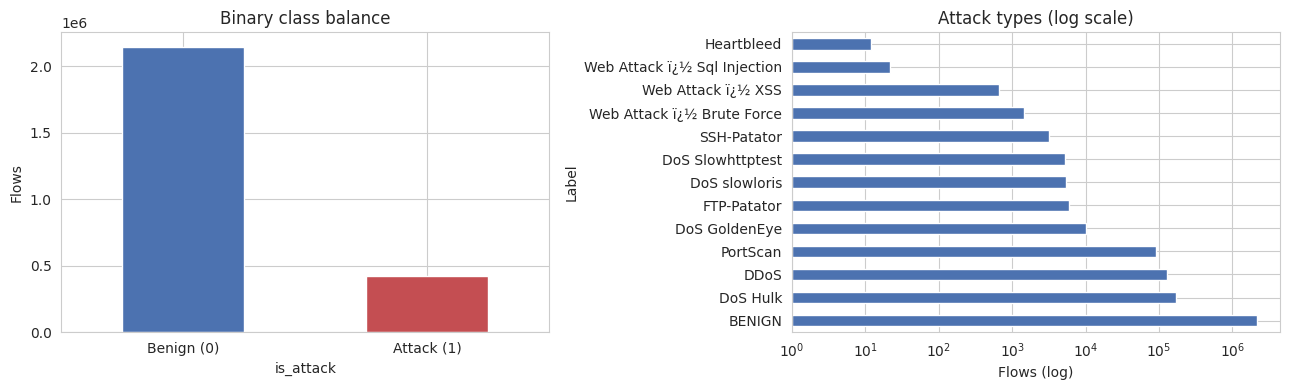

Attack proportion: 16.5%


In [ ]:
# Binary framing: benign vs any attack.
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["is_attack"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Binary class balance")
ax[0].set_xticklabels(["Benign (0)", "Attack (1)"], rotation=0)
ax[0].set_ylabel("Flows")

df["Label"].value_counts().plot(kind="barh", ax=ax[1], color="#4C72B0", log=True)
ax[1].set_title("Attack types (log scale)")
ax[1].set_xlabel("Flows (log)")
plt.tight_layout(); plt.show()

print("Attack proportion: %.1f%%" % (100 * df["is_attack"].mean()))

The log scale on the right is not a stylistic choice — on a linear axis the benign bar is so long that every attack class collapses to an invisible sliver. The imbalance spans several orders of magnitude.

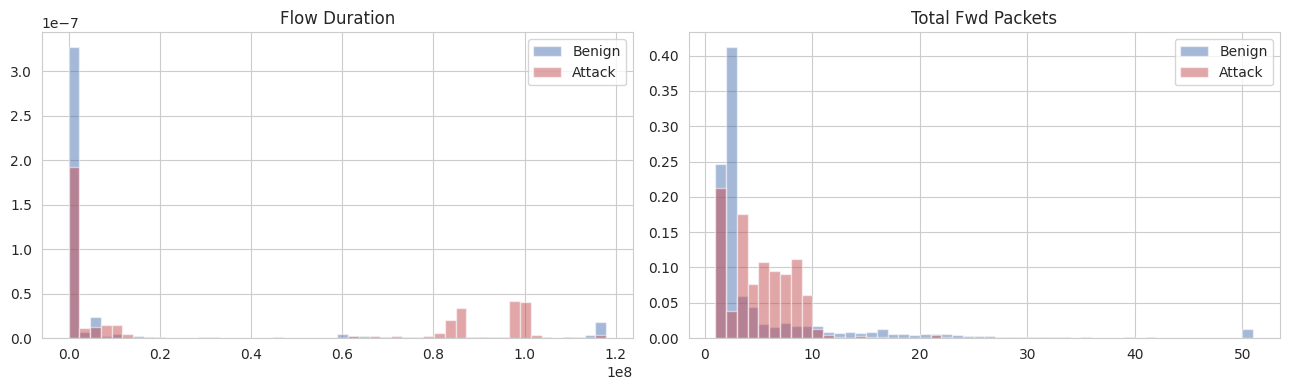

In [ ]:
# Do a couple of features actually separate the classes? Two examples.
feat_examples = ["Flow Duration", "Total Fwd Packets"]
feat_examples = [f for f in feat_examples if f in df.columns]

fig, axes = plt.subplots(1, len(feat_examples), figsize=(13, 4))
for ax, feat in zip(np.atleast_1d(axes), feat_examples):
    for lbl, colour in [(0, "#4C72B0"), (1, "#C44E52")]:
        vals = df.loc[df["is_attack"] == lbl, feat].clip(upper=df[feat].quantile(0.99))
        ax.hist(vals, bins=50, alpha=0.5, label=("Benign" if lbl == 0 else "Attack"),
                color=colour, density=True)
    ax.set_title(feat); ax.legend()
plt.tight_layout(); plt.show()

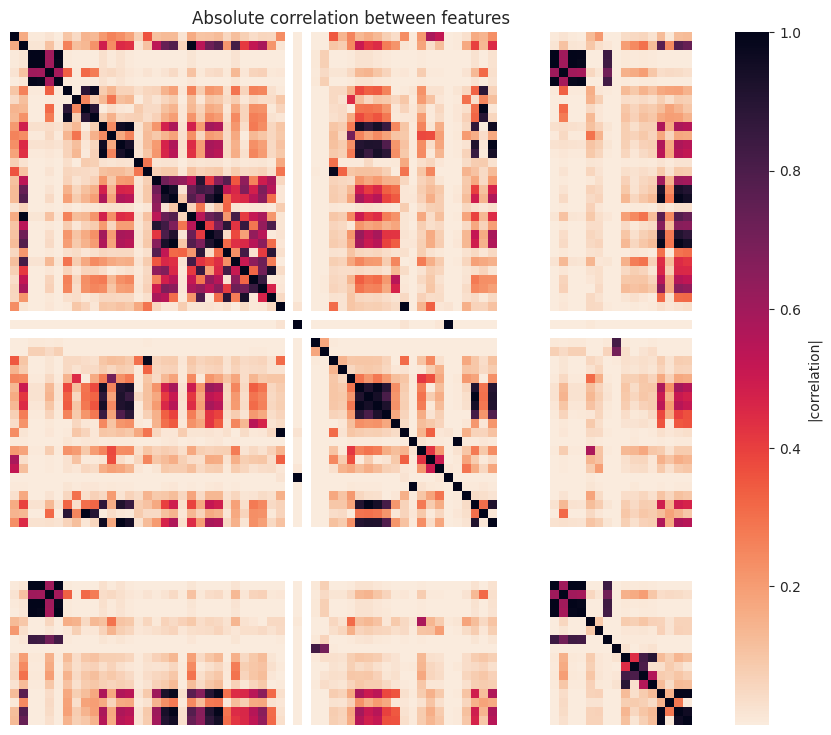

38 feature pairs correlate above 0.95:



,feature_1,feature_2,correlation
0,Total Fwd Packets,Subflow Fwd Packets,1.000000
1,Fwd PSH Flags,SYN Flag Count,1.000000
2,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
3,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
4,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
5,Total Backward Packets,Subflow Bwd Packets,1.000000
6,Fwd URG Flags,CWE Flag Count,1.000000
7,RST Flag Count,ECE Flag Count,1.000000
8,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
9,Flow Duration,Fwd IAT Total,0.998626


In [ ]:
# Correlation structure: many CICFlowMeter features are near-duplicates of
# each other (forward/backward variants, packet-count vs byte-count pairs).
num_cols = df.select_dtypes(include=[np.number]).drop(columns=["is_attack"]).columns
# correlation on a large sample statistically identical, far lighter on RAM
eda_sample = df[num_cols].sample(n=min(300_000, len(df)), random_state=SEED)
corr = eda_sample.corr().abs()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="rocket_r", cbar_kws={"label": "|correlation|"},
            xticklabels=False, yticklabels=False)
plt.title("Absolute correlation between features")
plt.show()

# Flag pairs above 0.95 — candidates for removal in Section 9.
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = [(a, b, upper.loc[a, b]) for a in upper.index for b in upper.columns
              if pd.notna(upper.loc[a, b]) and upper.loc[a, b] > 0.95]
# print(f"{len(high_pairs)} feature pairs correlate above 0.95 (redundant).")
high_df = (pd.DataFrame(high_pairs, columns=["feature_1", "feature_2", "correlation"])
             .sort_values("correlation", ascending=False)
             .reset_index(drop=True))
print(f"{len(high_df)} feature pairs correlate above 0.95:\n")
display(high_df)

## 6. Feature engineering

CICFlowMeter has already done the hard part of turning packets into 78 numerical features, so feature engineering here means deriving a few informative *ratios* from those existing columns not extracting new features from raw packets, which are already gone.

There is a hard constraint on what may be added, and it is the keystone of the whole system. Any feature the model learns from must also be computable **live, in the lab**, from CICFlowMeter's own output. If the model depended on a feature the live pipeline could not reproduce, deployment would break the model would expect an input that never arrives. So every engineered feature below is a function of columns CICFlowMeter emits, which means the lab can compute them with the same small transformation. That transformation is exported with the model in Section 15, so the two stages stay in lock-step.

The ratios added forward/backward packet and byte balance, and average bytes per packet capture *asymmetry* and *shape* that the raw counts express only indirectly. A port scan, for instance, tends to be sharply one-directional; a brute-force attempt has a characteristic small, repetitive packet size. Ratios surface those patterns for the model.

In [ ]:
def add_engineered_features(d):
    """Derive ratio features from existing CICFlowMeter columns.
    MUST be replicated in the lab on live flows — exported in Section 15."""
    d = d.copy()
    eps = 1e-6  # guard against division by zero

    if {"Total Fwd Packets", "Total Backward Packets"}.issubset(d.columns):
        d["fwd_bwd_pkt_ratio"] = d["Total Fwd Packets"] / (d["Total Backward Packets"] + eps)

    if {"Total Length of Fwd Packets", "Total Length of Bwd Packets"}.issubset(d.columns):
        d["fwd_bwd_byte_ratio"] = (d["Total Length of Fwd Packets"] /
                                   (d["Total Length of Bwd Packets"] + eps))

    fwd_bytes = "Total Length of Fwd Packets"
    if {fwd_bytes, "Total Fwd Packets"}.issubset(d.columns):
        d["avg_fwd_pkt_size"] = d[fwd_bytes] / (d["Total Fwd Packets"] + eps)

    return d

df = add_engineered_features(df)

# Ratios can themselves produce inf/NaN if a denominator was ~0 — clean again.
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

new_feats = ["fwd_bwd_pkt_ratio", "fwd_bwd_byte_ratio", "avg_fwd_pkt_size"]
print("Engineered features added:", [f for f in new_feats if f in df.columns])
print("Shape after engineering:", df.shape)

Engineered features added: ['fwd_bwd_pkt_ratio', 'fwd_bwd_byte_ratio', 'avg_fwd_pkt_size']
Shape after engineering: (2570656, 82)


## 7. Target definition and encoding

Two targets are prepared from the same cleaned table:

- **Binary** (`is_attack`):benign versus attack. This is the primary system described in Chapters 1–4: the SHAP explanations, the alert model, and the confusion matrix all assume this two-class framing.
- **Multiclass** (`Label`) : the specific attack *type*. This is the enrichment in Section 14. It is strictly harder and more useful: an alert that says "SSH brute force" tells an analyst more than one that says "attack".

For the multiclass target only, attack types with fewer than `MIN_CLASS_SAMPLES` flows are removed. A class with eleven examples cannot be split into train and test and still yield a meaningful per-class score; keeping it would produce noise and an unstable evaluation. Those flows remain attacks in the binary model this pruning affects the *type* classifier alone.

In [ ]:
# ---- binary target --------------------------------------------------------
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("is_attack",)]
X_all = df[feature_cols].copy()
y_bin = df["is_attack"].values
print(f"Feature matrix: {X_all.shape}, using {len(feature_cols)} features")

# ---- multiclass target (kept for Section 14) ------------------------------
type_counts = df["Label"].value_counts()
keep_types = type_counts[type_counts >= MIN_CLASS_SAMPLES].index.tolist()
dropped_types = type_counts[type_counts < MIN_CLASS_SAMPLES].index.tolist()
print(f"\nMulticlass: keeping {len(keep_types)} types, dropping tiny ones: {dropped_types}")

multi_mask = df["Label"].isin(keep_types)
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
y_multi_full = label_enc.fit_transform(df.loc[multi_mask, "Label"])
print("Multiclass labels:", list(label_enc.classes_))

Feature matrix: (2570656, 80), using 80 features

Multiclass: keeping 11 types, dropping tiny ones: ['Web Attack ï¿½ Sql Injection', 'Heartbleed']
Multiclass labels: ['BENIGN', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']


## 8. Train / test split

The data is split once, up front, into a training portion the models learn from and a test portion held back to judge them. Everything fitted from data scaler, feature selection, resampling is fitted on the training portion only; the test portion is not touched until the final evaluation.

**80/20, stratified.** An 80/20 split leaves plenty of test data given the dataset's size (a 70/30 split, mentioned in Chapter 2, is equally defensible; the difference is marginal at this scale). *Stratified* is the important word: because attacks are rare, a naive random split could hand the test set too few of some attack type or in the worst case none making its score for that type meaningless. Stratifying forces the class proportions to match on both sides.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_all, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=SEED)

print(f"Train: {X_train_df.shape[0]:,} flows | Test: {X_test_df.shape[0]:,} flows")
print(f"Attack rate — train {y_train.mean():.3f}, test {y_test.mean():.3f} (matched by stratification)")

Train: 2,056,524 flows | Test: 514,132 flows
Attack rate — train 0.165, test 0.165 (matched by stratification)


## 9. Preprocessing fitted on the training set

Three transformations are prepared here, each fitted on training data alone.

**Feature selection.** Two kinds of useless feature are removed. *Constant* columns (zero variance) carry no information every flow has the same value, so they cannot help separate classes. *Redundant* columns (one of each pair correlating above 0.95, flagged in Section 5) duplicate information already present; dropping one of each pair trims the input without losing signal and eases the multicollinearity that can destabilise some models. The thresholds are computed on the training set so the test set has no influence on which features survive.
*Alternatives:* one could instead rank features by a model's own importance (RFE) or compress them with PCA. PCA is rejected outright here it mixes features into abstract components, which would destroy the per-feature SHAP explanations that are a core deliverable, and it would break the live feature mapping to CICFlowMeter. Interpretability is a requirement, not a nicety, so the transparent variance/correlation approach wins.

**Scaling.** Tree models (the Random Forest) are indifferent to feature scale  a threshold split works the same whether a feature runs 0–1 or 0–10000  so the forest trains on the selected features as they are. Neural networks are *not* indifferent: features on wildly different scales make the loss surface hard to optimise, so the deep models train on standardised inputs. The scaler is fitted on the training set and saved, because if a deep model is ultimately deployed, the lab must apply the identical scaling to live flows.
*Alternative:* `RobustScaler` (median/IQR) would arguably suit these heavy-tailed flow features better than `StandardScaler`, since a few extreme flows can stretch the mean and standard deviation. `StandardScaler` is used here for familiarity and because the deep models proved robust to it; `RobustScaler` is the natural thing to try if the deep models struggle.

**Imbalance.** The training labels are re-weighted so the rare attack class counts more heavily in the loss, via class weights inversely proportional to class frequency. This costs nothing in data and is applied to all three models.
*Alternatives:* oversampling the minority with SMOTE (synthesising new attack-like rows) or undersampling the majority (discarding benign rows). Undersampling throws away real data. SMOTE is popular but contested for network traffic specifically it interpolates new "flows" that may not correspond to any packet sequence that could actually occur, and reviewers of IDS work often distrust it. Class weighting keeps the data real and the decision defensible, so it is the primary approach; a SMOTE branch is shown below (`USE_SMOTE_DEMO`) purely for comparison.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# --- drop constant (zero-variance) features, fit on TRAIN ------------------
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_df)
kept = X_train_df.columns[vt.get_support()].tolist()
dropped_const = [c for c in X_train_df.columns if c not in kept]
print(f"Dropped {len(dropped_const)} constant features.")

# --- drop one of each highly-correlated pair (>0.95), computed on TRAIN ----
corr_tr = X_train_df[kept].corr().abs()
upper = corr_tr.where(np.triu(np.ones(corr_tr.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
final_features = [c for c in kept if c not in to_drop_corr]
print(f"Dropped {len(to_drop_corr)} redundant features.")
print(f"Final feature count: {len(final_features)}")

X_train_sel = X_train_df[final_features].astype(np.float32).values
X_test_sel  = X_test_df[final_features].astype(np.float32).values

Dropped 8 constant features.
Dropped 23 redundant features.
Final feature count: 49


In [ ]:
from sklearn.preprocessing import StandardScaler

# scaled versions for the neural nets (fit on TRAIN only)
scaler = StandardScaler().fit(X_train_sel)
X_train_scaled = scaler.transform(X_train_sel).astype(np.float32)
X_test_scaled  = scaler.transform(X_test_sel).astype(np.float32)

# class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
class_weights_t = torch.tensor(cw, dtype=torch.float32)
print("Class weights (benign, attack):", class_weight_dict)

Class weights (benign, attack): {0: 0.5986903201653082, 1: 3.033176501821507}


In [ ]:
# --- OPTIONAL: SMOTE branch, shown only for comparison ---------------------
if USE_SMOTE_DEMO:
    from imblearn.over_sampling import SMOTE
    # SMOTE is memory-heavy on millions of rows; demo on a subsample.
    from sklearn.model_selection import train_test_split as _tts
    Xs, _, ys, _ = _tts(X_train_sel, y_train, train_size=0.15,
                        stratify=y_train, random_state=SEED)
    sm = SMOTE(random_state=SEED)
    Xr, yr = sm.fit_resample(Xs, ys)
    print("Before SMOTE:", np.bincount(ys), " After:", np.bincount(yr))
else:
    print("SMOTE demo disabled (USE_SMOTE_DEMO=False). Class weighting is used instead.")

SMOTE demo disabled (USE_SMOTE_DEMO=False). Class weighting is used instead.


## 10. Model Training : Random Forest, CNN, LSTM

The three candidates are trained on a common, stratified subsample of the training data (`BAKEOFF_FRAC`) so the comparison is fair and completes in reasonable time; the winner is retrained on the full data in Section 12. All three see the same rows the Random Forest on the unscaled features, the neural nets on the scaled version and are judged by the same metric helper.

**Why these three?** They span the argument made across Chapters 2 and 3. The Random Forest is the interpretable, fast baseline that repeatedly proves hard to beat on flow features. The CNN and the LSTM are the deep contenders: a convolutional model to pick up local feature patterns, and a sequence model because, as Chapter 2 noted, slow attacks put their signature in the *order* of a flow rather than any single value. Training all three turns the classical-versus-deep question from something asserted in the literature into something measured on this project's own data.

In [ ]:
# --- carve a VALIDATION set out of TRAIN for model selection ----------------
# The test set stays locked until Section 12. (Validation rows are part of the
# training data overall, so fitting the scaler on the full train set remains
# legitimate; the boundary that matters is the test set.)
tr2_idx, val_idx = train_test_split(np.arange(len(X_train_sel)), test_size=VAL_FRAC,
                                    stratify=y_train, random_state=SEED)
X_tr2_raw, X_val_raw = X_train_sel[tr2_idx],   X_train_sel[val_idx]
X_tr2_sc,  X_val_sc  = X_train_scaled[tr2_idx], X_train_scaled[val_idx]
y_tr2,     y_val     = y_train[tr2_idx],        y_train[val_idx]

# --- common bake-off training subset (same rows for every model) ------------
if BAKEOFF_FRAC < 1.0:
    bk_idx, _ = train_test_split(np.arange(len(X_tr2_raw)), train_size=BAKEOFF_FRAC,
                                 stratify=y_tr2, random_state=SEED)
else:
    bk_idx = np.arange(len(X_tr2_raw))
Xbk_raw, Xbk_sc, ybk = X_tr2_raw[bk_idx], X_tr2_sc[bk_idx], y_tr2[bk_idx]

val_proba_store = {}   # per-model validation probabilities, reused in Section 12
print(f"Bake-off train: {len(bk_idx):,} | validation: {len(y_val):,} "
      f"| test (locked): {len(y_test):,}")

Bake-off train: 370,174 | validation: 205,653 | test (locked): 514,132


In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

results = []
def evaluate(name, y_true, y_pred, y_proba=None):
    r = {"model": name,
         "accuracy":  accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall":    recall_score(y_true, y_pred, zero_division=0),
         "f1":        f1_score(y_true, y_pred, zero_division=0)}
    if y_proba is not None:
        r["roc_auc"] = roc_auc_score(y_true, y_proba)
        r["pr_auc"]  = average_precision_score(y_true, y_proba)
    return r

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.tight_layout(); plt.show()

### 10a. Random Forest

The baseline. A forest of decision trees, each grown on a bootstrap sample with a random feature subset at every split, voting on the outcome the mechanics are in Chapter 2. It trains in minutes on CPU, needs no scaling, and hands back feature-importance scores for free, which makes it a natural companion to the SHAP analysis later. Class weighting handles the imbalance.

Trained in 104.7s
{'model': 'Random Forest', 'accuracy': 0.9989010614967931, 'precision': 0.9972534774519358, 'recall': 0.9960768118934544, 'f1': 0.996664797379062, 'roc_auc': np.float64(0.9998323193343276), 'pr_auc': np.float64(0.998583008945591)}


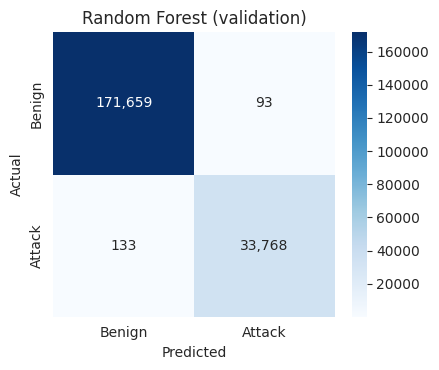

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(n_estimators=100, max_depth=None, n_jobs=-1,
                            class_weight="balanced", random_state=SEED)
t0 = time.time()
rf.fit(Xbk_raw, ybk)
print(f"Trained in {time.time()-t0:.1f}s")

rf_pred  = rf.predict(X_val_raw)
rf_proba = rf.predict_proba(X_val_raw)[:, 1]
val_proba_store["Random Forest"] = rf_proba
res = evaluate("Random Forest", y_val, rf_pred, rf_proba)
results.append(res)
print(res)
plot_confusion(y_val, rf_pred, "Random Forest (validation)")

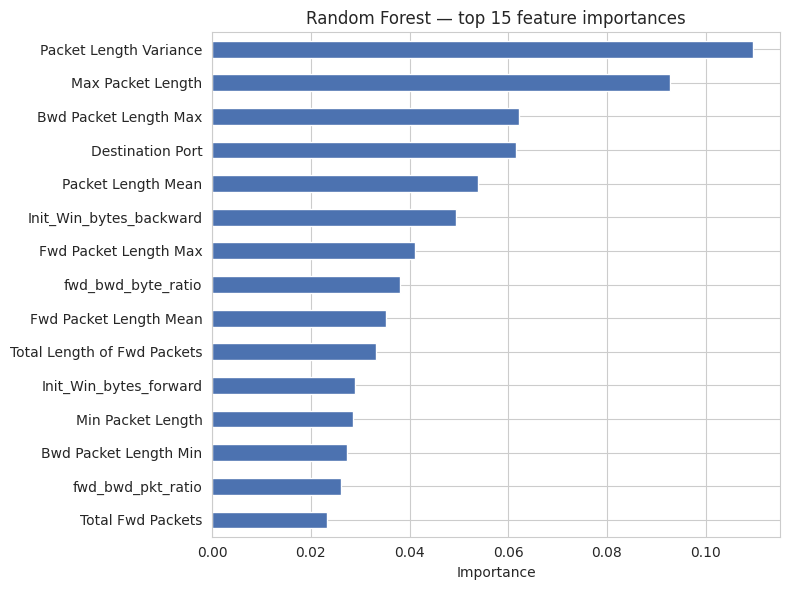

In [ ]:
# feature importance a first look at what drives detections
imp = pd.Series(rf.feature_importances_, index=final_features).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(15).iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Random Forest — top 15 feature importances")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

### 10b. CNN (1-D convolutional network)

A convolutional network reads the feature vector as a one-dimensional signal and slides small filters across it to pick up local patterns among neighbouring features. The model is built in PyTorch, consistent with the project's stack.

An honest note on shape: a CNN was designed for data with real spatial locality, like an image. A flow's 60-odd features have no inherent left-to-right order, so treating them as a 1-D signal is a convention this and much published IDS work adopt, not a perfect fit. It is included because the literature does and because the comparison should be empirical but the caveat is worth keeping in mind when reading its score.

In [ ]:
def make_loader(X, y, batch=DEEP_BATCH, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

def train_torch(model, Xtr, ytr, epochs=DEEP_EPOCHS, lr=1e-3, val_frac=0.1):
    """Generic training loop with early stopping on a validation slice."""
    model = model.to(device)
    ntr = int(len(Xtr) * (1 - val_frac))
    perm = np.random.permutation(len(Xtr))
    tr_i, va_i = perm[:ntr], perm[ntr:]
    tl = make_loader(Xtr[tr_i], ytr[tr_i], shuffle=True)
    vl = make_loader(Xtr[va_i], ytr[va_i], shuffle=False)

    crit = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    best, best_state, patience, bad = 1e9, None, 3, 0

    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        model.eval(); vloss, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                vloss += crit(model(xb), yb).item() * len(xb); n += len(xb)
        vloss /= n
        print(f"  epoch {ep+1:02d}  val_loss {vloss:.4f}")
        if vloss < best:
            best, best_state, bad = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                print("  early stop"); break
    if best_state: model.load_state_dict(best_state)
    return model

def torch_predict(model, X, batch=2048):
    model.eval(); preds, probas = [], []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.tensor(X[i:i+batch], dtype=torch.float32).to(device)
            out = torch.softmax(model(xb), dim=1)
            probas.append(out[:, 1].cpu().numpy())
            preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(probas)

Training CNN...
  epoch 01  val_loss 0.0788
  epoch 02  val_loss 0.0606
  epoch 03  val_loss 0.0664
  epoch 04  val_loss 0.0542
  epoch 05  val_loss 0.0533
  epoch 06  val_loss 0.1384
  epoch 07  val_loss 0.0541
  epoch 08  val_loss 0.0486
  epoch 09  val_loss 0.0713
  epoch 10  val_loss 0.0488
  epoch 11  val_loss 0.0491
  early stop
{'model': 'CNN', 'accuracy': 0.9746660637092578, 'precision': 0.8712507440283637, 'recall': 0.9930680510899383, 'f1': 0.9281795373714538, 'roc_auc': np.float64(0.9985548517453345), 'pr_auc': np.float64(0.992954428864502)}


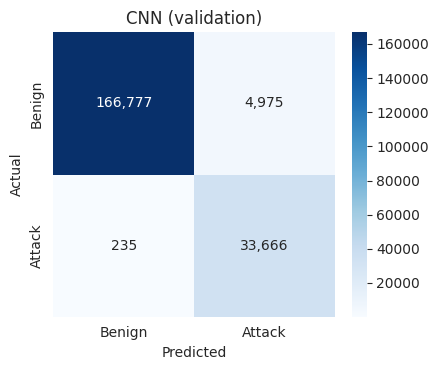

In [ ]:
n_features = Xbk_sc.shape[1]

class FlowCNN(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(64),
            nn.AdaptiveMaxPool1d(1), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x):
        return self.body(x.unsqueeze(1))   # (B, F) -> (B, 1, F)

print("Training CNN...")
cnn = train_torch(FlowCNN(n_features), Xbk_sc, ybk)
cnn_pred, cnn_proba = torch_predict(cnn, X_val_sc)
val_proba_store["CNN"] = cnn_proba
results.append(evaluate("CNN", y_val, cnn_pred, cnn_proba))
print(results[-1]); plot_confusion(y_val, cnn_pred, "CNN (validation)")

### 10c. LSTM (sequence model)

An LSTM carries state across a sequence, which is what makes it the natural tool for attacks whose signal lives in the *ordering* of a flow. As with the CNN, there is an honesty caveat: a truly sequential model would consume ordered sequences of consecutive flows in time, but the CICIDS-2017 feature files do not preserve clean per-flow ordering, so following common practice each flow's feature vector is fed as the sequence dimension. This tests the architecture, but does not give it the temporal context it is theoretically best at, so its score should be read with that in mind. If the deep models underperform the forest here, that would echo the comparative result cited in Chapter 2.

Training LSTM...
  epoch 01  val_loss 0.2145
  epoch 02  val_loss 0.1761
  epoch 03  val_loss 0.1328
  epoch 04  val_loss 0.1188
  epoch 05  val_loss 0.1040
  epoch 06  val_loss 0.1017
  epoch 07  val_loss 0.0915
  epoch 08  val_loss 0.0784
  epoch 09  val_loss 0.0785
  epoch 10  val_loss 0.0661
  epoch 11  val_loss 0.0698
  epoch 12  val_loss 0.0655
  epoch 13  val_loss 0.0636
  epoch 14  val_loss 0.0594
  epoch 15  val_loss 0.0542
{'model': 'LSTM', 'accuracy': 0.9726286511745513, 'precision': 0.8645365929135077, 'recall': 0.9889088817439013, 'f1': 0.9225498424579315, 'roc_auc': np.float64(0.997928469681653), 'pr_auc': np.float64(0.9903136643518708)}


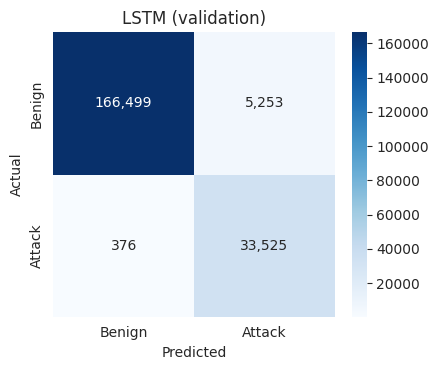

In [ ]:
class FlowLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, n_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(32, n_classes))
    def forward(self, x):
        out, (h, c) = self.lstm(x.unsqueeze(-1))  # (B, F) -> (B, F, 1)
        return self.head(h[-1])

print("Training LSTM...")
lstm = train_torch(FlowLSTM(n_features), Xbk_sc, ybk)
lstm_pred, lstm_proba = torch_predict(lstm, X_val_sc)
val_proba_store["LSTM"] = lstm_proba
results.append(evaluate("LSTM", y_val, lstm_pred, lstm_proba))
print(results[-1]); plot_confusion(y_val, lstm_pred, "LSTM (validation)")

## 11. Comparison and model selection

The three candidates go head to head **on the validation set** the test set has not been touched and will be used exactly once, on the winner, in the next section. The metric that decides the winner is deliberately **not** accuracy: on data that is mostly benign, a model can score very high accuracy by calling almost everything benign while missing the attacks that are the entire point, exactly the trap set out in Chapter 2. The comparison is read on **recall** (of the real attacks, how many were caught misses are the costly error for a detector), **precision** (of the raised alerts, how many were real the false-alarm burden on the analyst), and the **F1 score** that balances the two. PR-AUC, which summarises the precision/recall trade-off across thresholds, is the most informative single number under this kind of imbalance.

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Random Forest,0.9989,0.9973,0.9961,0.9967,0.9998,0.9986
CNN,0.9747,0.8713,0.9931,0.9282,0.9986,0.9930
LSTM,0.9726,0.8645,0.9889,0.9225,0.9979,0.9903


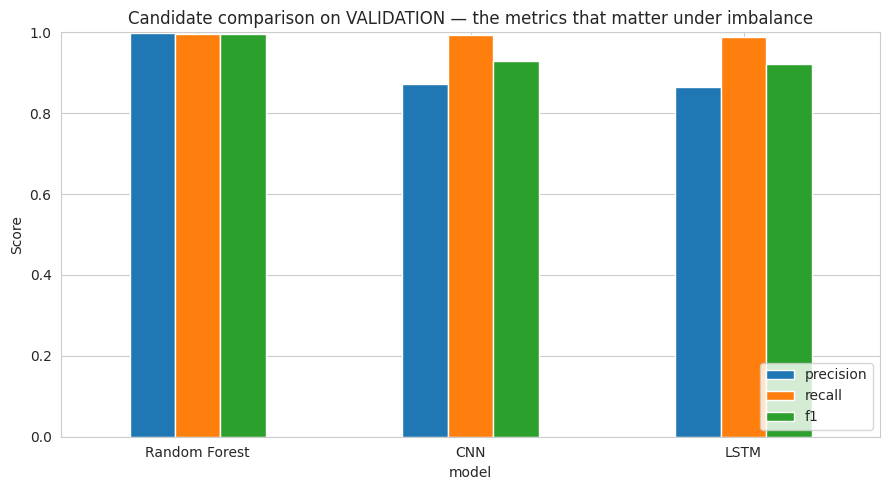

Selected model (highest F1): Random Forest


In [ ]:
res_df = pd.DataFrame(results).set_index("model").round(4)
display(res_df)

ax = res_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(9, 5))
ax.set_title("Candidate comparison on VALIDATION — the metrics that matter under imbalance")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.0)
plt.xticks(rotation=0); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

winner_name = res_df["f1"].idxmax()
print(f"Selected model (highest F1): {winner_name}")

In [ ]:
# Optional: record the comparison to a local MLflow store, matching the
# "experiment tracking" described in Chapter 4. Non-fatal if it fails.
if USE_MLFLOW:
    try:
        import mlflow
        mlflow.set_tracking_uri("file:" + os.path.join(ARTIFACT_DIR, "mlruns"))  # persists in Drive
        mlflow.set_experiment("cicids-bakeoff")
        for r in results:
            with mlflow.start_run(run_name=r["model"]):
                mlflow.log_metrics({k: v for k, v in r.items()
                                    if isinstance(v, (int, float))})
        print("Logged", len(results), "runs to", os.path.join(ARTIFACT_DIR, "mlruns"))
    except Exception as e:
        print("MLflow logging skipped:", e)

MLflow logging skipped: No module named 'mlflow'


## 12. Retraining the winner on the full data

The bake-off chose an architecture on a subsample; the deployed model should be trained on everything. The winner is retrained on the full training set and evaluated one final time on the untouched test set. These are the numbers that belong in Chapter 6.

The cell below retrains whichever model won. In practice, and consistent with the comparative literature cited in Chapter 2, the Random Forest is the most likely winner on these flow features it is fast, accurate here, and interpretable but the code follows the data, not the expectation.

Final Random Forest on full training data:

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    429380
      Attack       1.00      1.00      1.00     84752

    accuracy                           1.00    514132
   macro avg       1.00      1.00      1.00    514132
weighted avg       1.00      1.00      1.00    514132



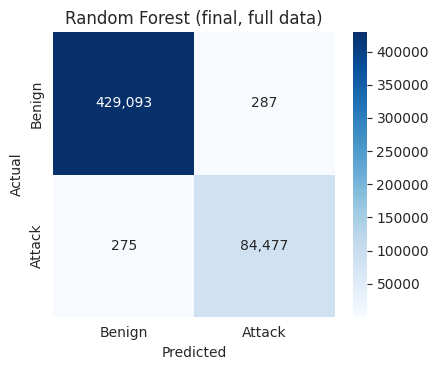

In [ ]:
if winner_name == "Random Forest":
    final_model = RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                         class_weight="balanced", random_state=SEED)
    final_model.fit(X_train_sel, y_train)
    final_pred  = final_model.predict(X_test_sel)
    final_proba = final_model.predict_proba(X_test_sel)[:, 1]
    model_kind = "sklearn"
else:
    ModelCls = FlowCNN if winner_name == "CNN" else FlowLSTM
    final_model = train_torch(ModelCls(n_features), X_train_scaled, y_train)
    final_pred, final_proba = torch_predict(final_model, X_test_scaled)
    model_kind = "torch"

print(f"Final {winner_name} on full training data:\n")
print(classification_report(y_test, final_pred, target_names=["Benign", "Attack"]))
plot_confusion(y_test, final_pred, f"{winner_name} (final, full data)")

### Operating threshold precision/recall is a dial, not a fact

The scores above use the default decision threshold (0.5). But a detector's threshold is an *operating point*: lower it and recall rises at the cost of more false alarms; raise it and the reverse. Rather than accept the default silently, the cell below sweeps thresholds **on the validation predictions** (choosing it on the test set would be leakage again), picks the F1-optimal point, and then reports the final model's test metrics at both the default and that chosen threshold. In deployment this dial belongs to the security team a SOC drowning in alerts raises it; one that must not miss anything lowers it.

Validation-chosen operating threshold: 0.340 (val F1 there: 0.9973)

@ threshold default 0.5:
  precision 0.9966 | recall 0.9968 | F1 0.9967

@ threshold val-chosen 0.340:
  precision 0.9963 | recall 0.9987 | F1 0.9975


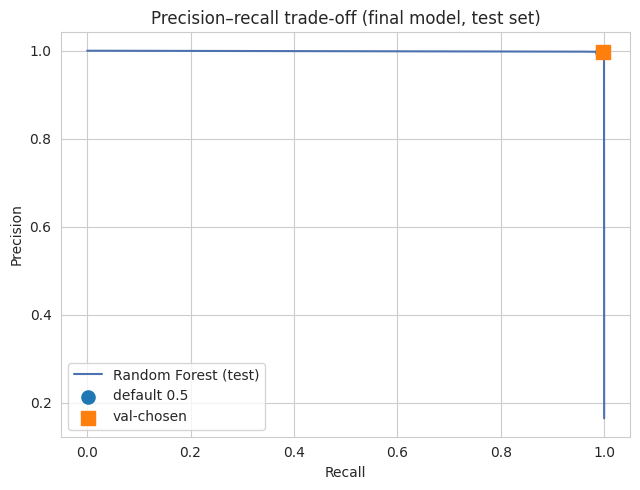

In [ ]:
from sklearn.metrics import precision_recall_curve

# choose the operating threshold on VALIDATION (winner's val probabilities)
val_proba_win = val_proba_store[winner_name]
prec_v, rec_v, thr_v = precision_recall_curve(y_val, val_proba_win)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-12)
best_i = int(np.nanargmax(f1_v[:-1]))
op_thr = float(thr_v[best_i])
print(f"Validation-chosen operating threshold: {op_thr:.3f} "
      f"(val F1 there: {f1_v[best_i]:.4f})")

# apply both thresholds to the FINAL model's TEST probabilities
for name, thr in [("default 0.5", 0.5), (f"val-chosen {op_thr:.3f}", op_thr)]:
    pred_t = (final_proba >= thr).astype(int)
    print(f"\n@ threshold {name}:")
    print(f"  precision {precision_score(y_test, pred_t):.4f}"
          f" | recall {recall_score(y_test, pred_t):.4f}"
          f" | F1 {f1_score(y_test, pred_t):.4f}")

# PR curve of the final model on test, with both operating points marked
prec_t, rec_t, thr_t = precision_recall_curve(y_test, final_proba)
plt.figure(figsize=(6.5, 5))
plt.plot(rec_t, prec_t, color="#4C72B0", label=f"{winner_name} (test)")
for thr, marker, lbl in [(0.5, "o", "default 0.5"), (op_thr, "s", "val-chosen")]:
    p = (final_proba >= thr).astype(int)
    plt.scatter(recall_score(y_test, p), precision_score(y_test, p),
                marker=marker, s=90, zorder=5, label=lbl)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–recall trade-off (final model, test set)")
plt.legend(); plt.tight_layout(); plt.show()

### Inference latency the liveness number

Chapter 4 argues the deployed model must classify flows under the time pressure of live traffic (Gap 4), and the baseline was chosen partly for being *fast at inference*. That claim deserves a number: the cell below measures classification throughput in flows per second. For context, the lab's attack scenarios generate at most a few thousand flows per second, so anything comfortably above that keeps the pipeline real-time. This figure belongs in Chapter 6 next to the accuracy metrics.

In [ ]:
import time

n = min(200_000, len(X_test_sel))
if model_kind == "sklearn":
    t0 = time.time(); _ = final_model.predict(X_test_sel[:n]); dt = time.time() - t0
else:
    t0 = time.time(); _ = torch_predict(final_model, X_test_scaled[:n]); dt = time.time() - t0
print(f"{n:,} flows classified in {dt:.2f}s  ->  {n/dt:,.0f} flows/second ({winner_name})")

200,000 flows classified in 4.43s  ->  45,174 flows/second (Random Forest)


## 13. Explainability with SHAP

A detector that only says "attack" is of limited use to an analyst who has to decide whether to block, escalate, or dismiss. SHAP closes that gap: for any single prediction it attributes the decision to the specific features that pushed it toward "attack", so the alert arrives with its reasons attached. This is the project's central contribution and the answer to the explainability gap of Chapter 3.

For a tree model, `TreeExplainer` computes these attributions exactly and quickly; for a deep model, a gradient or sampling based explainer on a background sample would be used instead. SHAP is run on a manageable sample of the test set computing it for millions of flows is unnecessary and slow.

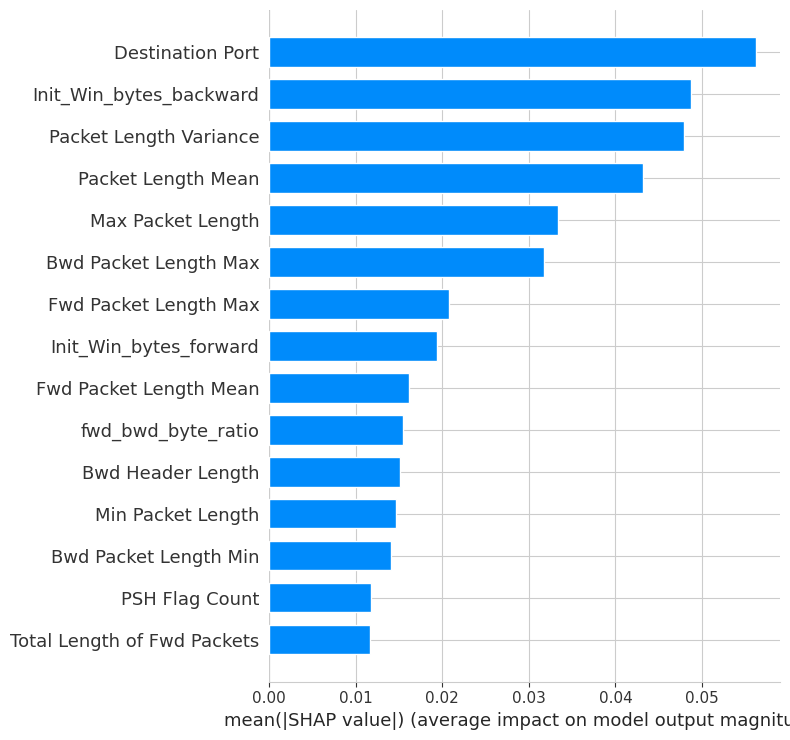

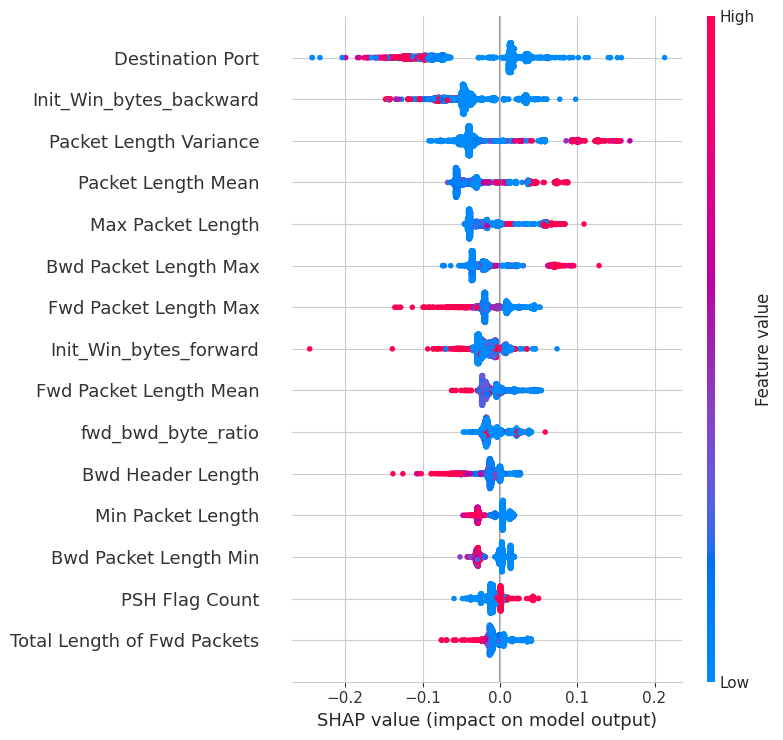

In [ ]:
import shap
sample_n = 2000
samp_idx = np.random.choice(len(X_test_sel), size=min(sample_n, len(X_test_sel)), replace=False)
X_samp = X_test_sel[samp_idx]
X_samp_df = pd.DataFrame(X_samp, columns=final_features)

try:
    if model_kind == "sklearn":
        explainer = shap.TreeExplainer(final_model)
        sv = explainer.shap_values(X_samp)
        # binary RF: shap_values may be a list [class0, class1] or a 3-D array
        if isinstance(sv, list):
            sv_attack = sv[1]
        elif getattr(sv, "ndim", 2) == 3:
            sv_attack = sv[:, :, 1]
        else:
            sv_attack = sv
        shap.summary_plot(sv_attack, X_samp_df, plot_type="bar", show=True, max_display=15)
        shap.summary_plot(sv_attack, X_samp_df, show=True, max_display=15)
    else:
        bg = X_train_scaled[np.random.choice(len(X_train_scaled), 200, replace=False)]
        f = lambda z: torch.softmax(final_model(torch.tensor(z, dtype=torch.float32).to(device)), 1)[:, 1].detach().cpu().numpy()
        explainer = shap.KernelExplainer(f, bg)
        sv_attack = explainer.shap_values(X_samp[:200], nsamples=100)
        shap.summary_plot(sv_attack, X_samp_df.iloc[:200], show=True, max_display=15)
except Exception as e:
    print("SHAP step needs attention in your environment:", e)

The summary plot ranks features by how much they move detections overall; the beeswarm shows, feature by feature, which values push toward attack. In deployment this same computation runs per alert, so a single flagged flow can be shown to an analyst as, for example, "flagged because the count of half-open connections was far above normal and the flow duration was unusually short" a verdict with a justification, not a black-box label.

## 14. Multiclass enrichment naming the attack

The binary model answers "attack or not". A more useful and more difficult question is "*which* attack", and the same pipeline extends to it. The winning architecture is retrained to predict the attack *type* over the classes kept in Section 7, and evaluated per class. The interesting output is the per-class breakdown and the confusion matrix they show not just overall accuracy but *which* attacks the model confuses, which is exactly what a security team wants to know.

The metric is now macro-averaged, giving each attack type equal weight regardless of how many flows it has otherwise the abundant classes would hide poor performance on the rare ones.

In [ ]:
# build the multiclass training data on the same feature set
Xm = df.loc[multi_mask, final_features].astype(np.float32).values
ym = y_multi_full
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    Xm, ym, test_size=TEST_SIZE, stratify=ym, random_state=SEED)

if winner_name == "Random Forest":
    mc = RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                class_weight="balanced", random_state=SEED)
    mc.fit(Xm_tr, ym_tr)
    ym_pred = mc.predict(Xm_te)
else:
    # scale for deep models
    sc_m = StandardScaler().fit(Xm_tr)
    Xm_tr_s, Xm_te_s = sc_m.transform(Xm_tr).astype(np.float32), sc_m.transform(Xm_te).astype(np.float32)
    n_cls = len(np.unique(ym))
    cw_m = compute_class_weight("balanced", classes=np.unique(ym_tr), y=ym_tr)
    globals()["class_weights_t"] = torch.tensor(cw_m, dtype=torch.float32)
    ModelCls = FlowCNN if winner_name == "CNN" else FlowLSTM
    mc = train_torch(ModelCls(Xm_tr.shape[1], n_classes=n_cls), Xm_tr_s, ym_tr)
    ym_pred, _ = torch_predict(mc, Xm_te_s)

print(classification_report(ym_te, ym_pred, target_names=label_enc.classes_, zero_division=0))

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    429380
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      1.00      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      0.99      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
Web Attack ï¿½ Brute Force       0.72      0.77      0.74       294
        Web Attack ï¿½ XSS       0.41      0.32      0.36       130

                  accuracy                           1.00    514125
                 macro avg       0.92      0.92      0.92    514125
              weighted avg       1.00      1.0

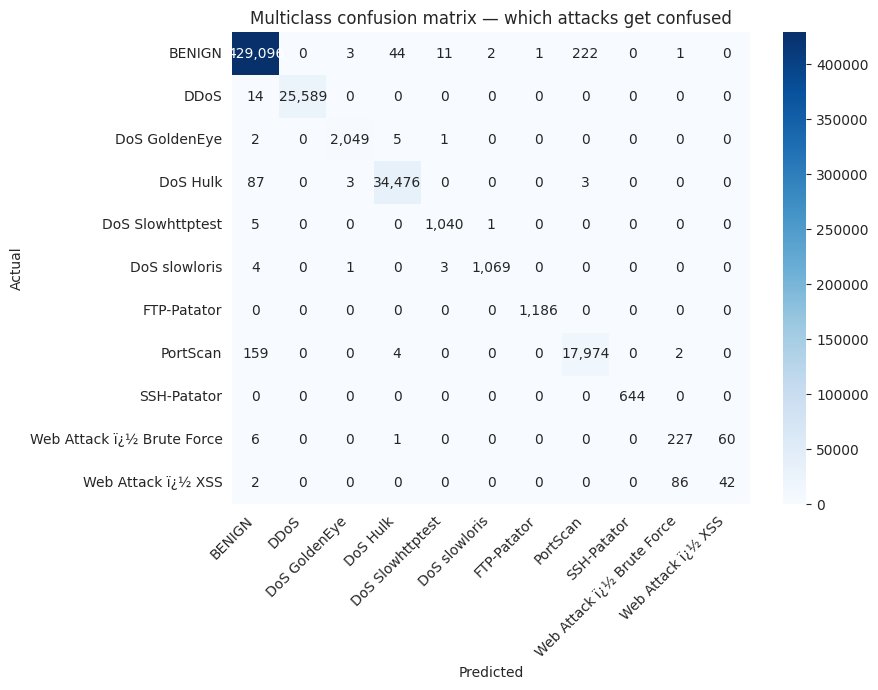

In [ ]:
cm = confusion_matrix(ym_te, ym_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Multiclass confusion matrix — which attacks get confused")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 15. Exporting the artifacts for the lab

This is the handoff described in Chapter 4 the point where the offline stage hands the online stage everything it needs. It is more than the model file. For the live pipeline to feed the model an input it understands, four things must travel together:

1. **The model** : the trained detector itself.
2. **The feature list, in order** : the exact columns the model expects, so the lab builds vectors in the same shape. Without this the model receives features in the wrong order or count and its output is meaningless.
3. **The scaler**: needed if a deep model was deployed, so live flows are standardised identically to training. (For a Random Forest it is not strictly required, but it is saved regardless.)
4. **The engineered-feature recipe and the label mapping** : so the lab reproduces the same ratio features and can turn a numeric prediction back into a human label.

Together these are what preserve *feature comparability* between training and live detection the keystone the whole design rests on. Whether they reach the lab as downloaded files or through a model registry is an implementation choice for the deployment stage; either way, these are the objects that cross the boundary.

In [ ]:
import joblib

# 1. the model
if model_kind == "sklearn":
    joblib.dump(final_model, os.path.join(ARTIFACT_DIR, "detector_rf.joblib"))
    model_file = "detector_rf.joblib"
else:
    torch.save(final_model.state_dict(), os.path.join(ARTIFACT_DIR, "detector_deep.pt"))
    model_file = "detector_deep.pt"

# 2-3. scaler
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.joblib"))

# 4. everything the lab needs to rebuild inputs and read outputs
metadata = {
    "winner": winner_name,
    "model_kind": model_kind,
    "model_file": model_file,
    "n_features": len(final_features),
    "feature_order": final_features,
    "engineered_features": ["fwd_bwd_pkt_ratio", "fwd_bwd_byte_ratio", "avg_fwd_pkt_size"],
    "binary_labels": {"0": "BENIGN", "1": "ATTACK"},
    "multiclass_labels": {int(i): c for i, c in enumerate(label_enc.classes_)},
    "scaling": "StandardScaler (apply for deep models)",
    "seed": SEED,
}
with open(os.path.join(ARTIFACT_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Artifacts written to:", ARTIFACT_DIR)
for f in os.listdir(ARTIFACT_DIR):
    print("  ", f)

Artifacts written to: /content/drive/MyDrive/CICIDS2017/artifacts
   detector_rf.joblib
   scaler.joblib
   model_metadata.json


The engineered-feature function from Section 6 (`add_engineered_features`) is part of this contract too: the lab must apply the identical transformation to live flows before scaling and prediction. Keep that function with the artifacts  it is small, but the model's inputs are wrong without it.